# Homework 5: Model Selection and Extreme Values

BEE 4850/5850, Spring 2025

**Name**: Christine Swanson 

**ID**: cms549

> **Due Date**
>
> Friday, 5/2/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practicing approaches to
extreme value analysis and using information criteria to assess evidence
for models.

-   Problem 1 asks you to compare stationary and non-stationary block
    maxima models for daily maximum temperature data.
-   Problem 2 asks you to use peaks-over-thresholds modeling on the same
    dataset from Problem 1.
-   Problem 3 (only required for students in BEE 5850) asks you to
    compare several linear regression models for environmental
    influences on non-accidental death data.

### Load Packages

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [154]:
import random  # random number generation and seed-setting
import pandas as pd  # tabular data structure (similar to DataFrames)
import numpy as np  # numerical operations
import csv  # reads/writes .csv files
import scipy.stats as stats  # interface to work with probability distributions
import matplotlib.pyplot as plt  # plotting library
import seaborn as sns  # additional statistical plotting tools
from datetime import datetime, timedelta  # date and time handling
from scipy.stats import genextreme, poisson, genpareto # for GEV, Poisson, GPD distributions 
from scipy.optimize import minimize # for MLE 
from sklearn.linear_model import LinearRegression # linear regression for problem 3

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Let’s look at how (modeled) annual maximum temperatures have (or have
not) increased in Ithaca from 1850–2014. Model output from NOAA’s
GFDL-ESM4 climate model (one of the models used in the latest Climate
Model Intercomparison Project,
[CMIP6](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fcds.climate.copernicus.eu%2Fcdsapp%23%21%2Fdataset%2Fprojections-cmip6%3Ftab%3Doverview))
is available in `data/gfdl-esm4-tempmax-ithaca.csv`. While this model
output has not been bias-corrected, we won’t worry about that for the
purposes of this assignment. The temperature data is in degrees Celsius,
and the dates are provided as calendar dates.

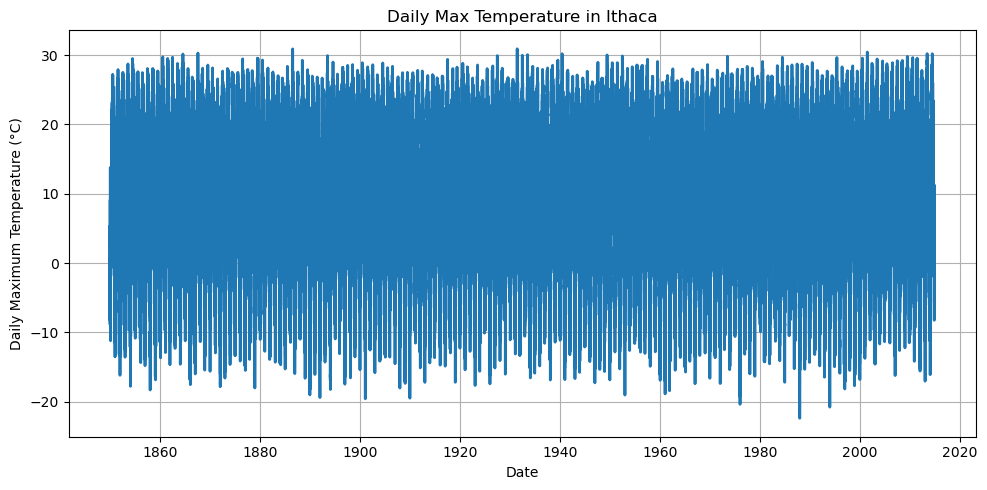

In [93]:
# adapted from ChatGPT (see references)
# Read the CSV file into a DataFrame
ithaca_dat = pd.read_csv("data/gfdl-esm4-tempmax-ithaca.csv")

# Convert the 'Day' column to datetime if it's not already
ithaca_dat['Day'] = pd.to_datetime(ithaca_dat['Day'])

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(ithaca_dat['Day'], ithaca_dat['TempMax'], linewidth=2)
plt.xlabel("Date")
plt.ylabel("Daily Maximum Temperature (°C)")
plt.title("Daily Max Temperature in Ithaca")
plt.grid(True)
plt.tight_layout()
plt.show()

**In this problem**:

-   Load the (daily maximum) temperature data from
    `data/gfdl-esm4-tempmax-ithaca.csv`. Find the modeled annual maximum
    temperatures and plot them.
-   Fit a stationary GEV model to the annual maximum series and report
    your parameter estimates. Plot the fitted distribution along with
    the data. What type of GEV distribution did you end up with? What is
    the 100-year return level?
-   Now fit a nonstationary GEV with respect to time (only the location
    parameter should be non-stationary),
    $y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling
    purposes, begin with $t=0$ corresponding to 1850).
-   What are the AIC values for each model? What can you conclude about
    the relative evidence for non-stationarity?


In [94]:
# after loading the data, find the modeled annual maximum temperature and plot them

# find modeled annual max temp 
# make a year column
ithaca_dat["Year"] = ithaca_dat["Day"].dt.year

# compute annual maxima and the corresponding dates
annual_maxima = ithaca_dat.loc[ithaca_dat.groupby('Year')['TempMax'].idxmax()]

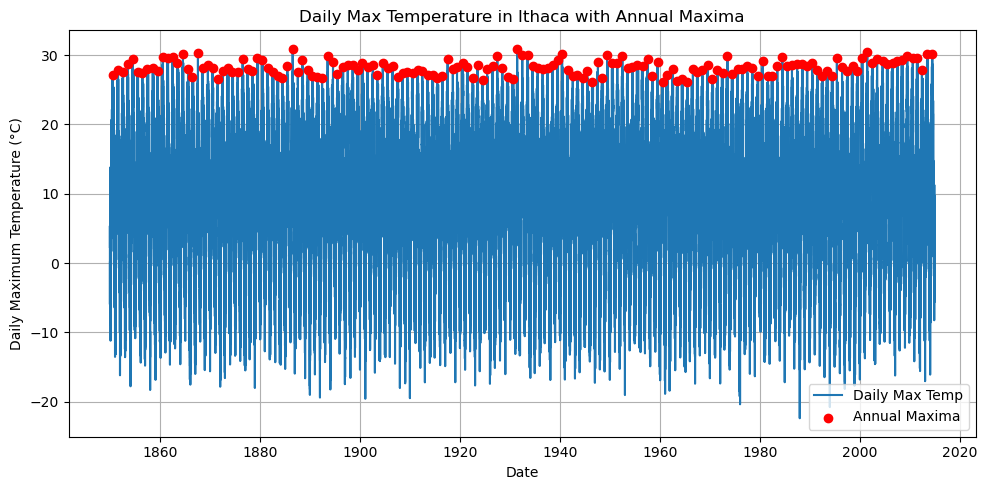

In [95]:
# plot the daily data
plt.figure(figsize=(10, 5))

plt.plot(ithaca_dat['Day'], ithaca_dat['TempMax'], linewidth=1.5, label='Daily Max Temp')

# overlay the annual maxima
plt.scatter(annual_maxima['Day'], annual_maxima['TempMax'], 
            color='red', label='Annual Maxima', zorder=5)

plt.xlabel("Date")
plt.ylabel("Daily Maximum Temperature (°C)")
plt.title("Daily Max Temperature in Ithaca with Annual Maxima")
plt.grid(True)
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

In [96]:
# fit a stationary GEV model to the annual maximum series and report parameter estimates

# list of the annual maxima data
annual_max_data = annual_maxima['TempMax'].values

# negative log-likelihood function for stationary GEV
# scipy.optimize minimizes the negative log-likelihood 

def gev_negloglik(params):
    # unpack GEV parameters: shape, loc, scale
    c, loc, scale = params

    # make sure scale is positive
    if scale <= 0:
        return np.inf

    # compute negative log likelihood
    return -np.sum(genextreme.logpdf(annual_max_data, c=c, loc=loc, scale=scale))

# initial guesses for parameters: [shape, location, scale]
init_param_vals = [0.1, np.mean(annual_max_data), np.std(annual_max_data)]
bounds = [(-1.0, 1.0), (-100, 100), (1e-6, 100)]

# optimize using scipy.optimize.minimize
result = minimize(gev_negloglik, init_param_vals, bounds = bounds, method='Nelder-Mead') # Julia default method is Nelder-Mead

# extract estimated parameters
shape_mle, loc_mle, scale_mle = result.x

# print the estimated parameters from stationary GEV fit
print("Stationary GEV MLE Parameters:")
print(f"Shape (ξ): {shape_mle:.2f}")
print(f"Location (μ): {loc_mle:.2f}")
print(f"Scale (σ): {scale_mle:.2f}")

Stationary GEV MLE Parameters:
Shape (ξ): 0.22
Location (μ): 27.83
Scale (σ): 1.02


In [97]:
# generate a range of x values for plotting the PDF
x_vals = np.linspace(min(annual_max_data), max(annual_max_data), 500)

# get the fitted PDF using MLE parameters (note: scipy uses shape = -ξ)
fitted_pdf = genextreme.pdf(x_vals, c=shape_mle, loc=loc_mle, scale=scale_mle)

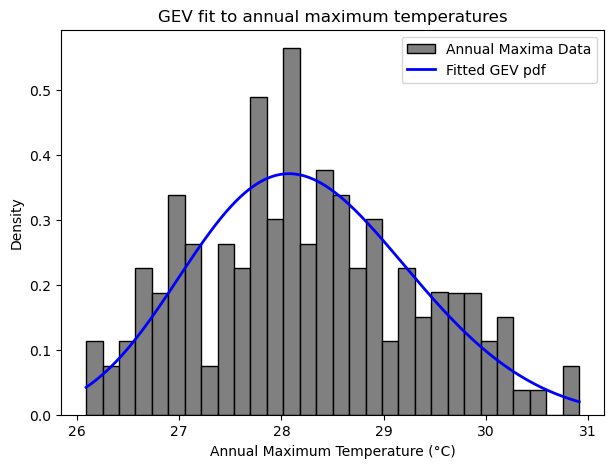

In [98]:
# plot the fitted distribution along with the data
# need to overlay the pdf of the fitted GEV on the data

plt.figure(figsize=(7, 5)) 

# the annual maxima data
plt.hist(annual_max_data, bins=30, density = True, color = "grey", 
         label = "Annual Maxima Data", edgecolor="black")

# the fitted GEV pdf
plt.plot(x_vals, fitted_pdf, 'blue', lw=2, label="Fitted GEV pdf")

plt.xlabel("Annual Maximum Temperature (°C)")
plt.ylabel("Density")
plt.title("GEV fit to annual maximum temperatures")
plt.legend()

plt.show()

In [144]:
# compute the 100-year return level

# Given MLE values for location (mu), scale (sigma), and shape (xi)
T = 100  # return period (years)
p = 1 - 1/T  # non-exceedance probability

# compute 100-year return level using quantile at 0.99
return_lvl_100 = genextreme.ppf(p, c=shape_mle, loc=loc_mle, scale=scale_mle)

# print 100-year return level
print(f"100-year return level (stationary GEV model): {return_lvl_100:.2f} °C")

100-year return level (stationary GEV model): 30.78 °C


*Question: What type of GEV distribution did you end up with? What is the 100-year return level?*

**RESPONSE: Because scipy's `genextreme` function shape parameter is the negative of the standard GEV shape parameter, this means the GEV distribution I ended up with is a Weibull distribution (ξ < 0). This means the distribution is bounded on the upper bound, which we can see from the above plot. The 100-year return level is 30.78 °C. This means that 30.78 °C is the temperature expected to be exceeded only once every 100 years, on average, based on the extreme temperature data I used to fit my stationary GEV model.**

In [100]:
# fit non-stationary GEV with respect to time 
# (only the location parameter should be non-stationary),
# # $y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling
# purposes, begin with $t=0$ corresponding to 1850)

# list of the annual maxima data
annual_max_data = annual_maxima['TempMax'].values

# define time variable starting from t=0 for year 1850
years = np.arange(1850, 1850 + len(annual_max_data))

# non-stationary GEV log-likelihood function: loc is μ(t) = μ0 + μ1 * t
def gev_negloglik_nonstationary(params):
    mu_0, mu_1, sigma, xi = params
    
    # compute the time-dependent location parameter μ(t)
    mu_t = mu_0 + mu_1 * years
    
    # make sure sigma > 0 
    if sigma <= 0:
        return np.inf

    # compute the negative log-likelihood
    log_likelihood = -np.sum(genextreme.logpdf(annual_max_data, c=xi, loc=mu_t, scale=sigma))
    
    return log_likelihood

# initial guesses for parameters: [mu0, mu1, sigma, xi]
init_param_vals = [np.mean(annual_max_data), 0.0, np.std(annual_max_data), 0.1]

# pptimize the log-likelihood function using scipy's minimize
result_nonstationary = minimize(gev_negloglik_nonstationary, init_param_vals, method='Nelder-Mead')

# extract the estimated parameters
mu_0_mle, mu_1_mle, sigma_mle, xi_mle = result_nonstationary.x

# Print the estimated parameters for the non-stationary GEV model
print("Non-Stationary GEV MLE Parameters:")
print(f"loc 0 (mu_0): {mu_0_mle:.2f}")
print(f"loc 1 (mu_1): {mu_1_mle:.3f}")
print(f"Scale (σ): {sigma_mle:.2f}")
print(f"Shape (ξ): {xi_mle:.2f}")

Non-Stationary GEV MLE Parameters:
loc 0 (mu_0): 23.91
loc 1 (mu_1): 0.002
Scale (σ): 1.02
Shape (ξ): 0.22


In [ ]:
# compute the AIC for each of the models 
# (stationary and nonstationary GEV models)

# AIC=2*k - 2(ll)
# where k is number of params
# ll is log-likelihood 

nll_stationary = gev_negloglik(result.x) 
k_stationary = 3
aic_stationary = 2 * k_stationary - 2 * -nll_stationary
print(f"Stationary GEV AIC: {aic_stationary:.2f}")

Stationary GEV AIC: 492.93


In [102]:
nll_nonstationary = gev_negloglik_nonstationary(result_nonstationary.x)
k_nonstationary = 4
aic_nonstationary = 2 * k_nonstationary - 2 * -nll_nonstationary
print(f"Non-Stationary GEV AIC: {aic_nonstationary:.2f}")

Non-Stationary GEV AIC: 493.59


*Question: What are the AIC values for each model? What can you conclude about the relative evidence for non-stationarity?*

**RESPONSE: The AIC value for the stationary GEV model is 492.93. The AIC value for the nonstationary GEV model is 493.59. Because these values are so close to one another, I can conclude that there is not sufficient evidence for a non-stationary GEV model. That is, it is inconclusive whether the daily maximum temperature data should or should not be modeled with a stationary or a non-stationary GEV.**

### Problem 2

Now let’s analyze how often of the Ithaca temperature data.

**In this problem**:

-   Suppose that we were interested in looking at temperature
    exceedances over 28°C. Decluster these occurrences and plot the
    number of exceedances by year. Have they increased over time?
-   Fit a stationary Poisson-GPD model for the exceedances. What does
    the GPD distribution look like?
-   From your model, estimate the 100-year return level. How does it
    differ from the 100-year return period from the stationary model in
    Problem 1? Why do you think it agrees or disagrees?

In [ ]:
# code modified from POT lecture, slide 19
# extremal index - choosing the minimum time gap for declustering exceedances

# identify indices where TempMax > 28°C
thresh = 28
S = np.where(ithaca_dat['TempMax'] > thresh)[0]  # indices of exceedances
N = len(S)

# calculate time gaps (in days) between consecutive exceedances
T = np.diff(S)

# estimate the extremal index θ
theta = 2 * np.sum(T)**2 / ((N - 1) * np.sum(T**2))
print(f"Extremal index (θ): {theta:.2f}")

# estimate average cluster size (1/θ)
avg_cluster_size = 1 / theta
print(f"Average cluster size: {avg_cluster_size:.0f} days")

Extremal index (θ): 0.48
Average cluster size: 2 days


In [147]:
# decluster the occurrences of 28 degrees C
# modified code from Peaks Over Threshold lecture, slide 14

# identify exceedances over 28 degrees C
ithaca_dat['exceedances'] = ithaca_dat['TempMax'] > 28

# decluster based on calculations above, so use gap of 2 days
gap_days = 2

# only keep the first exceedance after the gap
ithaca_dat['cluster'] = (ithaca_dat['exceedances'] != ithaca_dat['exceedances'].shift()).cumsum()

declustered = (
    ithaca_dat[ithaca_dat['exceedances']]
    .groupby('cluster')
    .first()  # take only the first exceedance in each cluster
    .reset_index()
)

# filter out clusters that are too close
declustered = declustered.sort_values('Day')
declustered['time_diff'] = declustered['Day'].diff().dt.days
declustered = declustered[(declustered['time_diff'].isna()) | (declustered['time_diff'] > gap_days)]

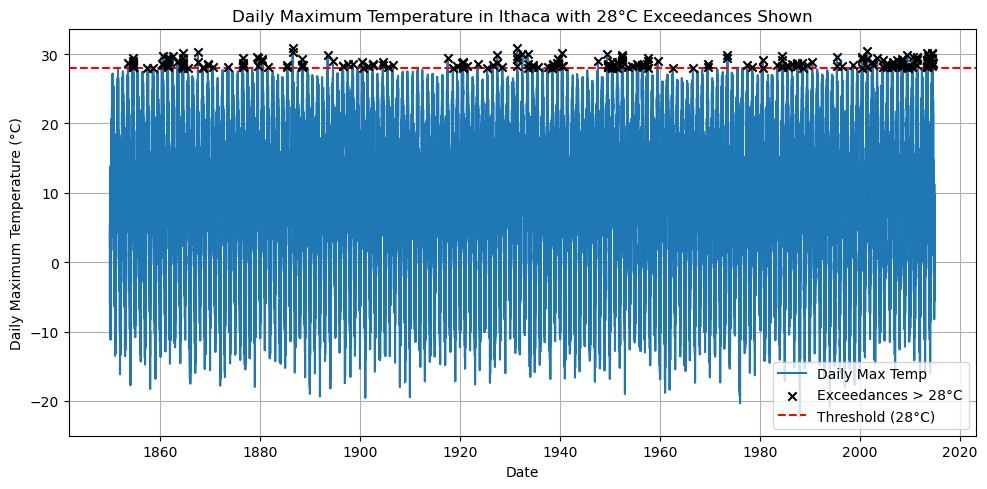

In [148]:
# adapted from POT lecture, slide 14
# boolean mask for exceedances over 28°C
exceed_mask = ithaca_dat['TempMax'] > 28

# plot daily temperature time series
plt.figure(figsize=(10, 5))
plt.plot(ithaca_dat['Day'], ithaca_dat['TempMax'], 
         label='Daily Max Temp', linewidth=1.5)

# overlay exceedances with markers
plt.scatter(
    ithaca_dat['Day'][exceed_mask],
    ithaca_dat['TempMax'][exceed_mask],
    color='black',
    label='Exceedances > 28°C',
    zorder=3,
    marker='x'
)

# add horizontal threshold line at 28°C
plt.axhline(28, color='red', linestyle='--', linewidth=1.5, label='Threshold (28°C)')

plt.xlabel("Date")
plt.ylabel("Daily Maximum Temperature (°C)")
plt.title("Daily Maximum Temperature in Ithaca with 28°C Exceedances Shown")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

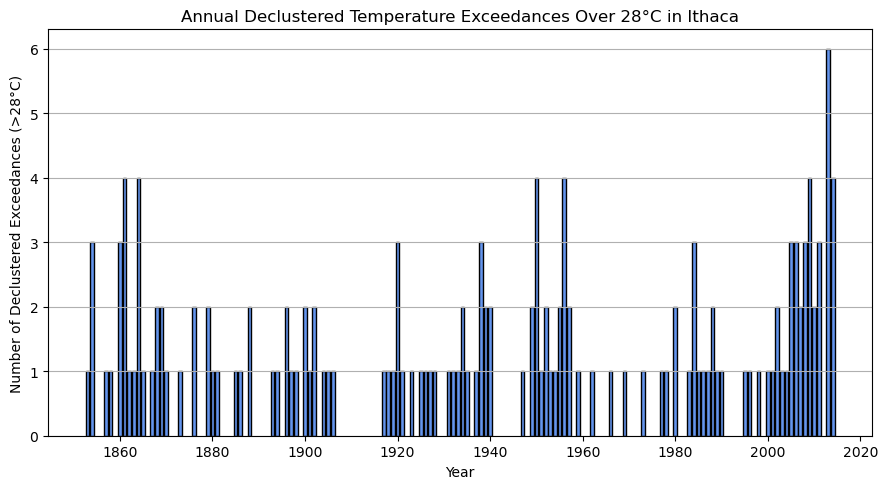

In [149]:
# plot number of exceedances by year
# have they increased over time?

# count the declustered exceedances by year
declustered['Year'] = declustered['Day'].dt.year
exceed_count_by_year = declustered.groupby('Year').size()

# plot the number of exceedances by year
plt.figure(figsize=(9, 5))

plt.bar(exceed_count_by_year.index, exceed_count_by_year.values, 
        color='cornflowerblue', edgecolor='black')
plt.xlabel("Year")
plt.ylabel("Number of Declustered Exceedances (>28°C)")
plt.title("Annual Declustered Temperature Exceedances Over 28°C in Ithaca")
plt.grid(axis='y')
plt.tight_layout()

plt.show()

*Question: Have they (temperature exceedances over 28 degrees C per year) increased over time?*

**RESPONSE: EXPLAIN APPROACH HERE...When declustering using a mean time between clusters of 2 days, it does not appear that the temperature exceedances over 28 degrees C per year have increased over time. This is because from the bar chart above, the bars seem pretty randomly dispersed and there is no clear pattern to the number of declustered exceedances over time.**

In [150]:
# Fit a stationary Poisson-GPD model for the exceedances 
# What does the GPD distribution look like?

threshold = 28
exceedances = ithaca_dat[ithaca_dat['TempMax'] > threshold]['TempMax'] - threshold

# use genpareto function 
# Fit GPD: returns shape (ξ), location (μ), and scale (σ)
shape_hat, loc_hat, scale_hat = genpareto.fit(exceedances, floc=0)  # fix loc=0 for standard excesses

print(f"Estimated GPD parameters:")
print(f"  ξ (shape): {shape_hat:.4f}")
print(f"  σ (scale): {scale_hat:.4f}")

Estimated GPD parameters:
  ξ (shape): -0.1877
  σ (scale): 0.8510


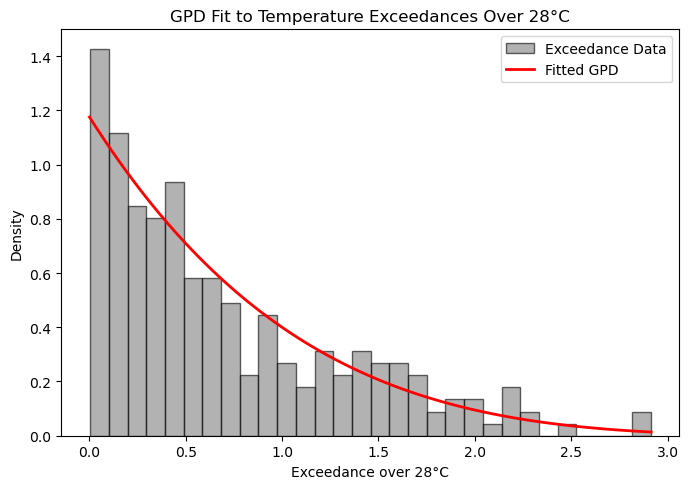

In [159]:
# plot the GPD distribution 
# with hist of exceedances over 28 degrees C
plt.figure(figsize=(7, 5))

x = np.linspace(0, exceedances.max(), 100)
pdf_vals = genpareto.pdf(x, c=shape_hat, loc=loc_hat, scale=scale_hat)

plt.hist(exceedances, bins=30, density=True, alpha=0.6, color='gray', edgecolor='black', label="Exceedance Data")
plt.plot(x, pdf_vals, 'r-', lw=2, label='Fitted GPD')

plt.xlabel("Exceedance over 28°C")
plt.ylabel("Density")
plt.title("GPD Fit to Temperature Exceedances Over 28°C")
plt.legend()
plt.tight_layout()

plt.show()

*Question: What does the GPD distribution look like?*

**RESPONSE:**

In [ ]:
# FIX THIS
# From your model, estimate the 100-year return level. 
# How does it differ from the 100-year return period from 
# the stationary model in Problem 1? Why do you think it agrees or disagrees?

# adapted from POT lecture, slide 27

# STEP 1: Fit Generalized Pareto Distribution (GPD)
# Note: scipy's genpareto uses (c, loc, scale): c = ξ, scale = σ, loc usually = 0
ξ_hat, loc_hat, σ_hat = genpareto.fit(exceedances, floc=0)

# STEP 2: Estimate Poisson rate λ (mean annual exceedance count)
exceed_counts = ithaca_dat[ithaca_dat['TempMax'] > threshold].groupby('Year').size().reset_index(name='count')
λ_hat = exceed_counts['count'].mean() # MLE of lambda for poisson is mean 

# STEP 3: Estimate 100-year return level using Poisson-GPD formula
T = 100  # years
RL_100 = threshold + (σ_hat / ξ_hat) * ((T * λ_hat) ** ξ_hat - 1)

# STEP 4: Print return level
print(f"Estimated 100-year return level (Poisson-GPD Model): {RL_100:.2f} °C")

Estimated 100-year return level (Poisson-GPD Model): 30.92 °C


*Question: How does it (the 100-yr return level from the Poisson-GPD Model) differ from the 100-year return period from the (GEV) stationary model in Problem 1? Why do you think it agrees or disagrees?*

**RESPONSE: The 100-yr return level from the Poisson-GPD model is 30.92°C, whereas the 100-yr return level for the stationary GEV model is 30.78°C. So, the return levels are very similar between both approaches (difference of 0.14°C). I think these results agree with each other because...CONTINUE HERE.**

### Problem 3

**This problem is only required for students in BEE 5850**.

Let’s examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html)) contains
data on the relationship between environmental conditions (temperature
and air quality) and deaths in Chicago from 1987–2000. The variables
are:

-   the total number of (non-accidental) deaths each day (`death`);
-   the median density over the city of large pollutant particles (PM10;
    `pm10median`);
-   the median density of smaller pollutant particles (PM2.5;
    `pm25median`);
-   the median concentration of ozone ($O_3$) in the air (`o3median`);
    the median concentration of sulfur dioxide ($SO_2$) in the air
    (`so2median`);
-   the time in days (`time`); and the daily mean temperature (`tmpd`).

The pollution variables have been standardized to represent deviations
from the overall median and the temperature is in Fahrenheit. The days
are given as a number of days relative to December 31, 1993. Note that
some values are missing; these can be treated as missing at random and
dropped in your regressions.

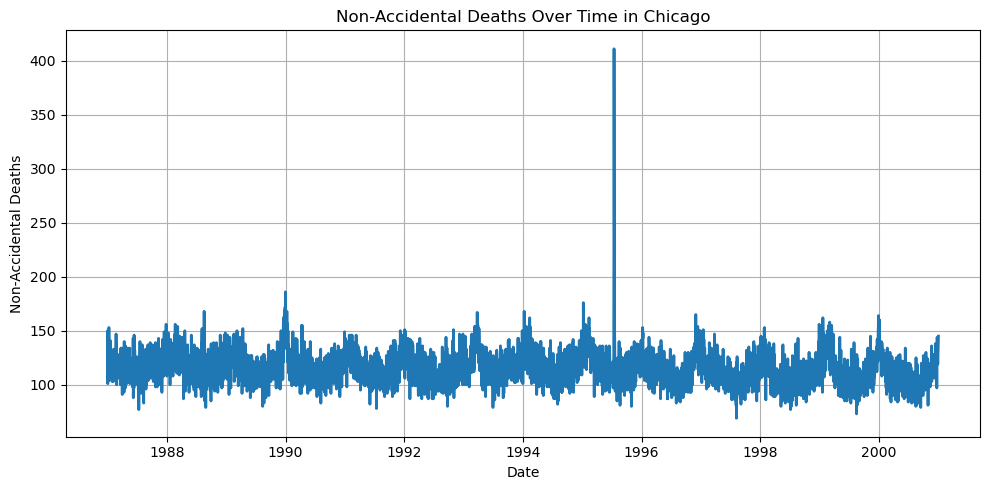

In [153]:
# adapted from ChatGPT (see references)
# Read the CSV file with specified delimiter and NA values
chicago_dat = pd.read_csv("data/chicago.csv", delimiter=',', header=0, na_values="NA")

# Define the reference date
day_zero = datetime.strptime("1993-12-31", "%Y-%m-%d")

# Add fractional day offset (0.5 days = 12 hours), then compute full dates
chicago_dat['Date'] = chicago_dat['time'].apply(lambda t: day_zero + timedelta(days=t + 0.5))

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(chicago_dat['Date'], chicago_dat['death'], linewidth=2)
plt.xlabel("Date")
plt.ylabel("Non-Accidental Deaths")
plt.title("Non-Accidental Deaths Over Time in Chicago")
plt.grid(True)
plt.tight_layout()
plt.show()

**In this problem**:

-   Load and plot the deaths data. Linearly regress the number of deaths
    against time and report the coefficients for the fitted model. Add
    the regression line to your plot. What does this regression tell
    you?
-   Now linearly regress the deaths data against temperature. Once
    again, report the coefficients, and add the regression line to your
    plot. What does this regression tell you about the influence of
    temperature?
-   Expand your previous model by regressing deaths against temperature
    and PM2.5 density. Report the coefficients and add this regression
    line to your plot.
-   Compute the AICs for the three fitted model and compare them. What
    do they tell you about the relative evidence for the influence of
    temperature and PM2.5 density on deaths? How do your conclusions
    based on AIC compare to those you might draw from your regression
    coefficients and plots?

In [ ]:
# COME BACK AND DROP MISSING DATA BEFORE FITTING THE LINEAR REGRESSION
# deaths data is plotted above
# linearly regress the number of deaths against time and report fitted regression coefficients
# Perform linear regression (death vs. time)
X = np.array((chicago_dat['time'])).reshape(-1, 1)  # time as independent variable
y = np.array(chicago_dat['death'])  # deaths as dependent variable

# Fit the linear model
model = LinearRegression()
model.fit(X, y)

# Get the regression coefficients
slope = model.coef_[0]
intercept = model.intercept_

# Generate the regression line
y_pred = model.predict(X)

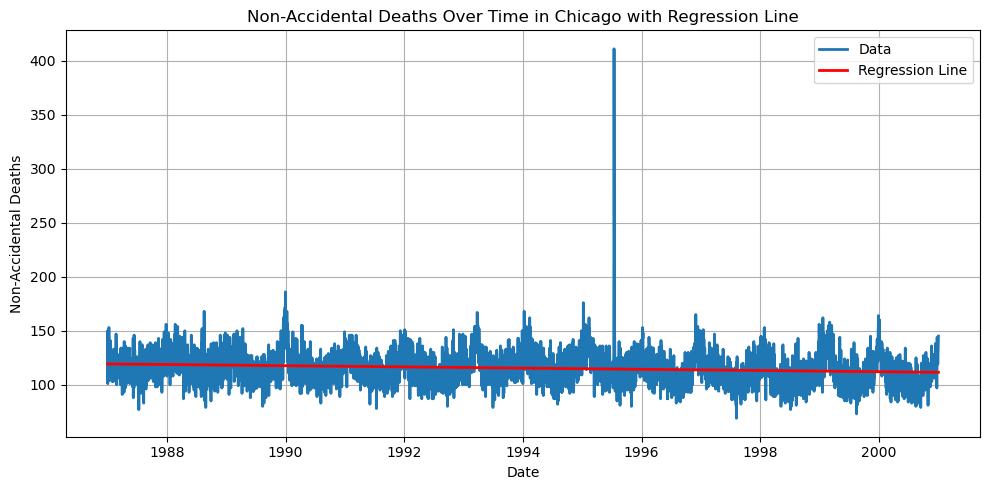

Linear Regression Coefficients:
Slope (Rate of change of deaths per day): -0.0015
Intercept (Initial number of deaths): 115.4189


In [156]:
# Plot the data and the regression line
plt.figure(figsize=(10, 5))
plt.plot(chicago_dat['Date'], chicago_dat['death'], label="Data", linewidth=2)
plt.plot(chicago_dat['Date'], y_pred, color='red', label="Regression Line", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Non-Accidental Deaths")
plt.title("Non-Accidental Deaths Over Time in Chicago with Regression Line")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the regression coefficients
print(f"Linear Regression Coefficients:")
print(f"Slope (Rate of change of deaths per day): {slope:.4f}")
print(f"Intercept (Initial number of deaths): {intercept:.4f}")

## References and Generative AI Acknowledgement 

OpenAI. (2025). ChatGPT (April 14 version) [Large language model]. https://openai.com/chatgpt [Accessed 14 April 2025]. 

- Problem 0: Setting up packages
    - Prompt I asked ChatGPT: "Convert these Julia packages to Python". That is, I asked it to convert the provided Julia packages to Python.
    - Date of prompt: 14 April 2025
    - Verified the code made sense and used directly from ChatGPT

- Problem 1: Converting provided Julia code to Python
    - Prompt I asked ChatGPT: "Convert this Julia code to Python: `ithaca_dat = CSV.read("data/gfdl-esm4-tempmax-ithaca.csv", DataFrame)
plot(ithaca_dat.Day, ithaca_dat.TempMax, lw=2, xlabel="Date", ylabel="Daily Maximum Temperature (°C)", legend=false)`
    - Date of prompt: 14 April 2025
    - Verified the code made sense and used directly from ChatGPT

- Problem 3: Converting provided Julia code to Python
    - Prompt I asked ChatGPT: "Convert this Julia code to Python: `chicago_dat = CSV.read("data/chicago.csv", DataFrame; delim=',', header=true, missingstring="NA")
day_zero = Date("1993-12-31")
chicago_dat.Date = day_zero .+ Day.(chicago_dat.time .+ 0.5)
plot(chicago_dat.Date, chicago_dat.death, lw=2, xlabel="Date", ylabel="Non-Accidental Deaths)", legend=false)`
    - Date of prompt: 14 April 2025
    - Verified the code made sense and used directly from ChatGPT

scipy.stats.genextreme documentation. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.genextreme.html. [Accessed 29 April 2025]. 